In [5]:
!pip install nltk
!pip install gensim
!pip install numpy
!pip install contractions
!pip install gradio

In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from tensorflow.keras.callbacks import EarlyStopping
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
df = pd.read_csv('/content/drive/MyDrive/AI PORTFOLIO/7. Racist Sexist or Not Dataset/train_racisit.csv')

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Total samples: 31962
label
0    29720
1     2242
Name: count, dtype: int64


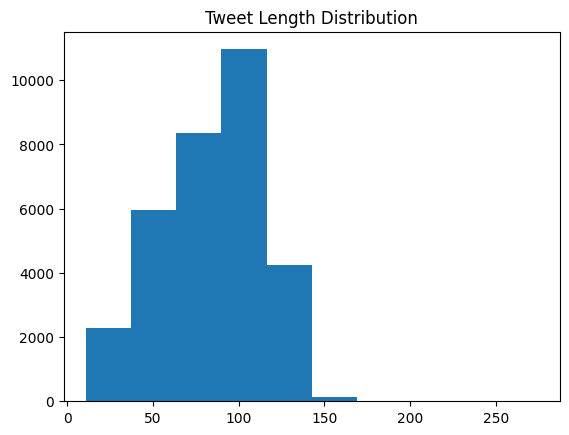

In [8]:
print("Total samples:", len(df))
print(df['label'].value_counts())

df['tweet_length'] = df['tweet'].apply(len)

plt.hist(df['tweet_length'])
plt.title("Tweet Length Distribution")
plt.show()

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['tweet'].apply(clean_text)

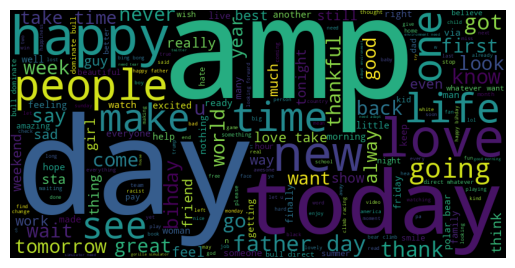

In [10]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

In [11]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f"Using max_len={max_len} (95th percentile)")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

vocab_size = len(tokenizer.word_index) + 1

Using max_len=11 (95th percentile)


In [12]:
model_rnn = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(X_train_pad, y_train, epochs=5,
                           validation_data=(X_test_pad, y_test),
                           callbacks=[EarlyStopping(patience=2)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9389 - loss: 0.2007 - val_accuracy: 0.9468 - val_loss: 0.1626
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9718 - loss: 0.0851 - val_accuracy: 0.9460 - val_loss: 0.1795
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9484 - val_loss: 0.2396


In [13]:
model_lstm = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train_pad, y_train, epochs=5,
                             validation_data=(X_test_pad, y_test),
                             callbacks=[EarlyStopping(patience=2)])

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9395 - loss: 0.2001 - val_accuracy: 0.9460 - val_loss: 0.1602
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9620 - loss: 0.1099 - val_accuracy: 0.9524 - val_loss: 0.1610
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9748 - loss: 0.0773 - val_accuracy: 0.9487 - val_loss: 0.1686


In [14]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model_w2v = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v = model_w2v.fit(X_train_pad, y_train, epochs=5,
                           validation_data=(X_test_pad, y_test),
                           callbacks=[EarlyStopping(patience=2)])

[==================================================] 100.0% 66.0/66.0MB downloaded
Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9286 - loss: 0.2154 - val_accuracy: 0.9334 - val_loss: 0.1997
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9376 - loss: 0.1824 - val_accuracy: 0.9396 - val_loss: 0.1862
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9433 - loss: 0.1675 - val_accuracy: 0.9412 - val_loss: 0.1810
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9480 - loss: 0.1544 - val_accuracy: 0.9440 - val_loss: 0.1810
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9526 - loss: 0.1428 - val_accuracy: 0.9481 - val_loss: 0.1697


In [15]:
def get_metrics(model):
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    }

results = pd.DataFrame([
    get_metrics(model_rnn),
    get_metrics(model_lstm),
    get_metrics(model_w2v)
], index=["RNN", "LSTM", "Word2Vec"])

print(results)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
          Accuracy  Precision    Recall        F1
RNN       0.948381   0.780992  0.405579  0.533898
LSTM      0.948694   0.718354  0.487124  0.580563
Word2Vec  0.948068   0.848958  0.349785  0.495441


In [16]:
from sklearn.metrics import classification_report
for model, name in [(model_rnn, 'RNN'), (model_lstm, 'LSTM'), (model_w2v, 'Word2Vec')]:
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, preds))

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== RNN Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5927
           1       0.78      0.41      0.53       466

    accuracy                           0.95      6393
   macro avg       0.87      0.70      0.75      6393
weighted avg       0.94      0.95      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== LSTM Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5927
           1       0.72      0.49      0.58       466

    accuracy                           0.95      6393
   macro avg       0.84      0.74      0.78      6393
weighted avg       0.94      0.95      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Word2Vec Classification Report ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5927
      

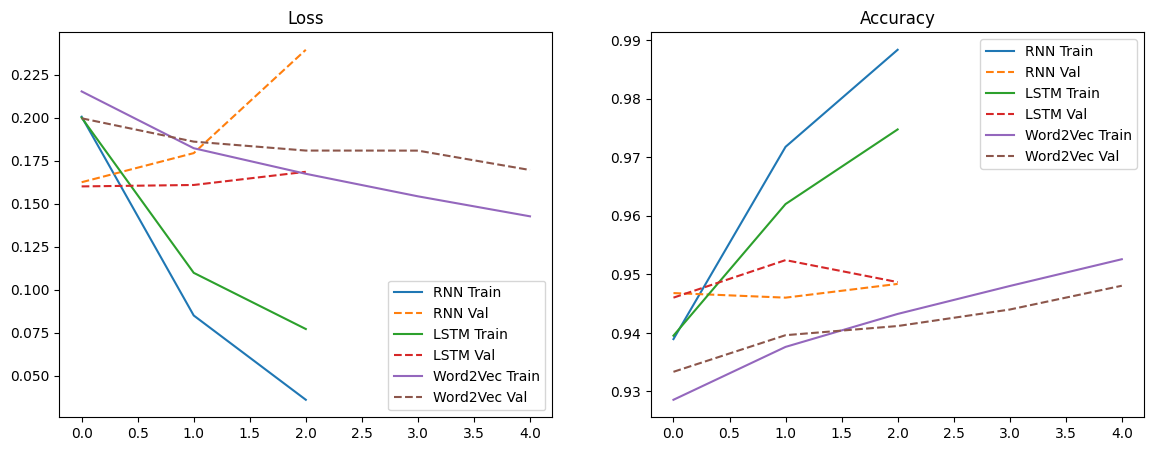

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for history, label in [(history_rnn, 'RNN'), (history_lstm, 'LSTM'), (history_w2v, 'Word2Vec')]:
    axes[0].plot(history.history['loss'], label=f'{label} Train')
    axes[0].plot(history.history['val_loss'], linestyle='--', label=f'{label} Val')
    axes[1].plot(history.history['accuracy'], label=f'{label} Train')
    axes[1].plot(history.history['val_accuracy'], linestyle='--', label=f'{label} Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()

In [18]:
errors = []

preds = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

for i in range(len(preds)):
    if preds[i] != y_test.iloc[i]:
        errors.append((X_test.iloc[i], y_test.iloc[i], preds[i]))

for i in range(3):
    print(errors[i])

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
('father great one brother following yeah married awesome gu', np.int64(1), array([0]))
('problem teach wrong teach', np.int64(1), array([0]))
('state million eligible voter million bothered vote', np.int64(0), array([1]))


In [19]:
import gradio as gr

def predict_tweet(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model_lstm.predict(padded)[0][0]
    return "Racist/Sexist 🔴" if pred > 0.5 else "Non-Racist/Sexist ✅"

gr.Interface(fn=predict_tweet, inputs="text", outputs="text",
             title="Tweet Sentiment Classifier").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55de5e8b7626975916.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
